In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("/Users/AlanHDLR/Desktop")

In [8]:
col_names = ["pregnant", "glucose", "bp", "skin", "insulin", "bmi", "pedigree", "age", "label"]
pima = pd.read_csv("diabetes.csv", header = None, names = col_names)
df = pima.iloc[1:,:]
df

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
764,10,101,76,48,180,32.9,0.171,63,0
765,2,122,70,27,0,36.8,0.34,27,0
766,5,121,72,23,112,26.2,0.245,30,0
767,1,126,60,0,0,30.1,0.349,47,1


In [10]:
# Seleccion de caracteristicas
feature_cols = ["pregnant", "glucose", "bp", "insulin", "bmi", "pedigree", "age"]
X = df[feature_cols]
y = df.label

In [12]:
# Creación de las bases de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [14]:
# sag : Stochastic Average Gradient
# newton-cg: Newton
# líblinear : Lybrary for large linear classification (Algoritmo Coordiante Descent)
# saga: Variate del metodo sag
# lbfgs: Limited-memory Broyden-Fletcher-Goldfarb-Shanno Algorithm

# Regresión logística con Solucionador (Solver): sag

In [17]:
model = LogisticRegression(solver = "sag")
clf = model.fit(X_train, y_train)

In [23]:
# Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(X_test)

# Impresión de coeficientes de la regresión de puntajes 
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable (Beta1, Beta2, ..., Beta7)", clf.coef_)

Intercepto (Beta 0) [-0.01183396]
Pesos de cada variable (Beta1, Beta2, ..., Beta7) [[ 0.05198087  0.01407928 -0.03083914  0.00116414 -0.00940247  0.00107874
  -0.0023005 ]]


In [25]:
# Evaluación de la precisión del modelo
score = model.score(X_test, y_test)
print("Score de precisión: ", score)

Score de precisión:  0.6428571428571429


In [27]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.89      0.76        99
           1       0.50      0.20      0.29        55

    accuracy                           0.64       154
   macro avg       0.58      0.54      0.52       154
weighted avg       0.61      0.64      0.59       154



# Regresión logística con Solucionador (Solver): newton-cg

In [30]:
model = LogisticRegression(solver = "newton-cg")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [-8.08948591]
Pesos (Betas):  [[ 0.1270843   0.03652997 -0.01510631 -0.00095841  0.0854402   0.63014482
   0.01165621]]
-------------------------------------------------------------------------
Precisión global:  0.7727272727272727
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.90      0.84        99
           1       0.75      0.55      0.63        55

    accuracy                           0.77       154
   macro avg       0.77      0.72      0.73       154
weighted avg       0.77      0.77      0.76       154



# Regresión logística con Solucionador (Solver): liblinear

In [34]:
model = LogisticRegression(solver = "liblinear")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [-5.38043607]
Pesos (Betas):  [[ 1.18843440e-01  2.87939298e-02 -1.90986684e-02 -3.17288706e-04
   5.28303250e-02  4.74897584e-01  3.80631679e-03]]
-------------------------------------------------------------------------
Precisión global:  0.7662337662337663
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        99
           1       0.74      0.53      0.62        55

    accuracy                           0.77       154
   macro avg       0.76      0.71      0.72       154
weighted avg       0.76      0.77      0.76       154



# Regresión logística con Solucionador (Solver): saga

In [38]:
model = LogisticRegression(solver = "saga")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [-0.00609245]
Pesos (Betas):  [[ 0.03027413  0.01389863 -0.03081344  0.00115712 -0.00955669  0.00048675
   0.00092679]]
-------------------------------------------------------------------------
Precisión global:  0.6493506493506493
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.89      0.77        99
           1       0.52      0.22      0.31        55

    accuracy                           0.65       154
   macro avg       0.60      0.55      0.54       154
weighted avg       0.62      0.65      0.60       154



# Regresión logística con Solucionador (Solver): lbfgs

In [42]:
model = LogisticRegression(solver = "lbfgs")
clf = model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intecepto (Beta0): ", clf.intercept_)
print("Pesos (Betas): ", clf.coef_)
print("-------------------------------------------------------------------------")
score = model.score(X_test, y_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------------")
print(classification_report(y_test, y_pred))

Intecepto (Beta0):  [-8.10385031]
Pesos (Betas):  [[ 0.12715736  0.03657086 -0.01508652 -0.00096267  0.08559413  0.63352855
   0.01168201]]
-------------------------------------------------------------------------
Precisión global:  0.7727272727272727
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.90      0.84        99
           1       0.75      0.55      0.63        55

    accuracy                           0.77       154
   macro avg       0.77      0.72      0.73       154
weighted avg       0.77      0.77      0.76       154



In [48]:
# Predicción de probabilidades para casos particulares 
y_pred_probs = clf.predict_proba(X_test)[:,1]
y_pred_probs[0:5]

array([0.43650665, 0.31967379, 0.15787844, 0.04340139, 0.19968346])

In [50]:
y_test[0:5]

286    0
102    0
582    0
353    0
727    0
Name: label, dtype: object

In [52]:
y_test = y_test.to_numpy()
y_test[0:5]

array(['0', '0', '0', '0', '0'], dtype=object)

In [54]:
y_test = [int(numeric_string) for numeric_string in y_test]
y_test[0:5]

[0, 0, 0, 0, 0]

In [56]:
import numpy as np
y_pred_probs = np.round(y_pred_probs,0)
y_pred_probs[0:5]

array([0., 0., 0., 0., 0.])

In [58]:
# Graficación de la curva ROC y cálculo del área bajo ella
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
# fpr = false positive rate
# tpr = true positive rate
# thresholds = límites para valores de p
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
auc = roc_auc_score(y_test, y_pred_probs)

Text(0.5, 1.0, 'Curva ROC para Regresión Logística')

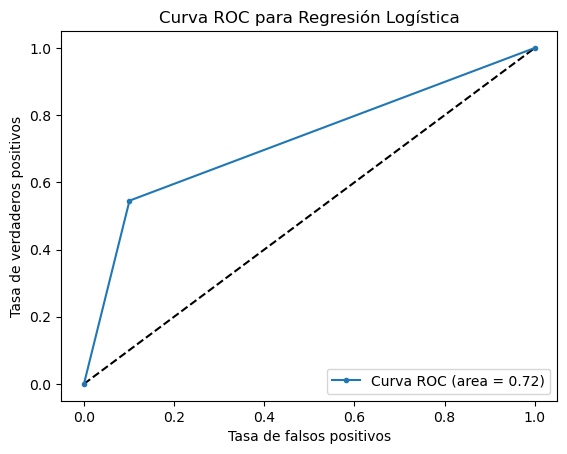

In [62]:
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, marker =".", label = "Curva ROC (area = %0.2f)" %auc)
plt.xlabel("Tasa de falsos positivos")      # False positive rate
plt.ylabel("Tasa de verdaderos positivos")  # True positive rate
plt.legend(loc = "lower right")
plt.title("Curva ROC para Regresión Logística")